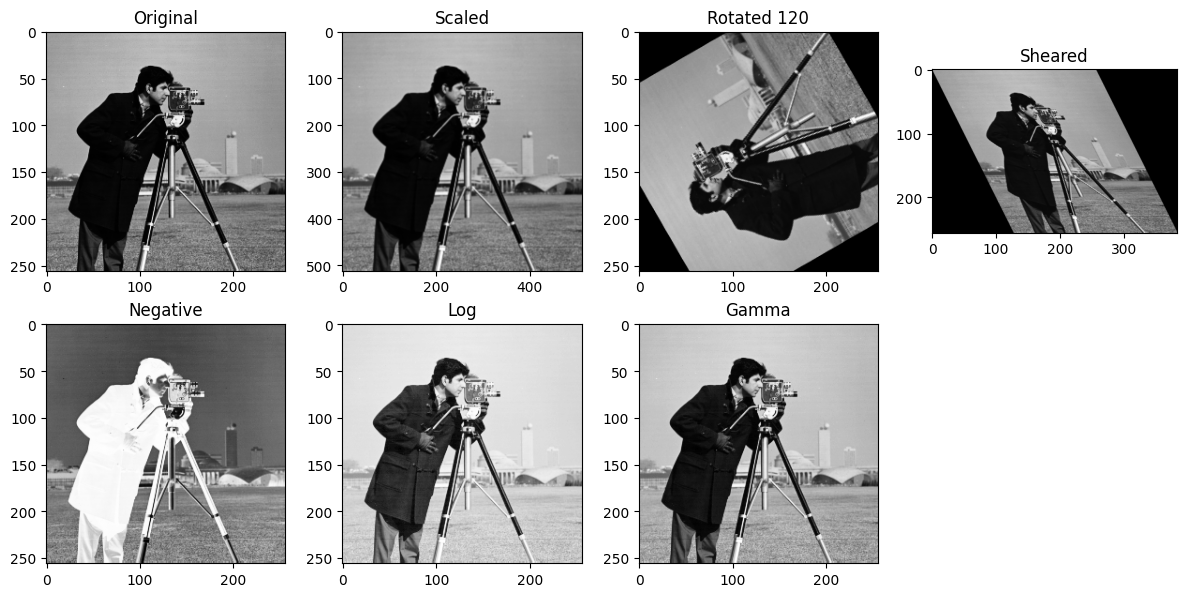

True

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
img = cv2.imread('images/cameraman.tif', 0)
rows, cols = img.shape

# --- Task 1: Geometric Transformations ---

# 1. Increase size
img_scaled = cv2.resize(img, (cols * 2, rows * 2))

# 2. Rotate by 120 degrees
matrix_rot = cv2.getRotationMatrix2D((cols/2, rows/2), 120, 1)
img_rotated = cv2.warpAffine(img, matrix_rot, (cols, rows))

# 3. Shear operation
matrix_shear = np.float32([[1, 0.5, 0], [0, 1, 0]])
img_sheared = cv2.warpAffine(img, matrix_shear, (int(cols * 1.5), rows))

# --- Task 2: Intensity Transformations ---

# 1. Negative
img_negative = 255 - img

# 2. Log Transformation
c = 255 / np.log(1 + np.max(img))
img_log = c * (np.log(1 + img.astype(float)))
img_log = np.uint8(img_log)

# 3. Power Law (Gamma)
gamma = 0.5
img_gamma = np.uint8(255 * (img / 255) ** gamma)

# --- Display Results ---
plt.figure(figsize=(12, 6))

plt.subplot(2, 4, 1); plt.imshow(img, cmap='gray'); plt.title('Original')
plt.subplot(2, 4, 2); plt.imshow(img_scaled, cmap='gray'); plt.title('Scaled')
plt.subplot(2, 4, 3); plt.imshow(img_rotated, cmap='gray'); plt.title('Rotated 120')
plt.subplot(2, 4, 4); plt.imshow(img_sheared, cmap='gray'); plt.title('Sheared')

plt.subplot(2, 4, 5); plt.imshow(img_negative, cmap='gray'); plt.title('Negative')
plt.subplot(2, 4, 6); plt.imshow(img_log, cmap='gray'); plt.title('Log')
plt.subplot(2, 4, 7); plt.imshow(img_gamma, cmap='gray'); plt.title('Gamma')

plt.tight_layout()
plt.show()

# Save an image file
cv2.imwrite('images/output_lab3.jpg', img_gamma)